In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(
    r"D:\Exo_Habit-AI\ExoPlanet.csv",
    dtype={"hd_name": str, "hip_name": str}
)

df.head()

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,7/23/2014,2011-08,7/23/2014,2,1,2,0,0,0,0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,9/19/2023,2023-08,9/19/2023,2,1,2,0,0,0,0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,5/14/2014,2008-01,5/14/2014,2,1,2,0,0,0,0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,9/4/2018,2017-03,9/6/2018,0,1,1,0,0,0,0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,4/25/2018,2009-10,5/14/2014,0,1,1,0,0,0,0


In [25]:
df.shape

(39251, 289)

In [26]:
df.describe()

,rowid,default_flag,sy_snum,sy_pnum,sy_mnum,cb_flag,disc_year,rv_flag,pul_flag,ptv_flag,...,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
count,39251.000000,39251.000000,39251.000000,39251.000000,39251.0,39251.000000,39251.000000,39251.000000,39251.000000,39251.000000,...,31175.000000,0.0,0.0,39251.000000,39251.000000,39251.000000,39251.000000,39251.000000,39251.000000,39251.000000
mean,19626.000000,0.154901,1.085297,1.918015,0.0,0.002420,2015.540190,0.251204,0.000331,0.000051,...,14.111483,NaN,NaN,1.022649,0.474154,0.196683,0.109934,0.110392,0.216733,0.005478
std,11330.932045,0.361814,0.308538,1.238266,0.0,0.049138,4.010208,0.433711,0.018196,0.007138,...,1.440036,NaN,NaN,1.124627,3.814243,0.887989,0.777398,0.936380,1.590283,0.153749
min,1.000000,0.000000,1.000000,1.000000,0.0,0.000000,1992.000000,0.000000,0.000000,0.000000,...,5.973000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9813.500000,0.000000,1.000000,1.000000,0.0,0.000000,2014.000000,0.000000,0.000000,0.000000,...,13.353000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,19626.000000,0.000000,1.000000,1.000000,0.0,0.000000,2016.000000,0.000000,0.000000,0.000000,...,14.415000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,29438.500000,0.000000,1.000000,2.000000,0.0,0.000000,2016.000000,1.000000,0.000000,0.000000,...,15.212000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,39251.000000,1.000000,4.000000,8.000000,0.0,1.000000,2026.000000,1.000000,1.000000,1.000000,...,17.475000,NaN,NaN,16.000000,70.000000,12.000000,13.000000,19.000000,32.000000,6.000000


In [27]:
selected_cols = [
    'pl_rade',      # Planet radius (Earth radii)
    'pl_bmasse',     # Planet mass (Earth mass)
    'pl_dens',      # Planet density (g/cm^3)
    'pl_eqt',       # Equilibrium temperature (K)
    'pl_orbper',    # Orbital period (days)
    'sy_dist',      # Distance from host star (pc)
    'st_spectype',  # host star type/spectral type
    'st_lum',       # Stellar Luminosity (log(solar))
    'st_teff',      # Stellar effective temperature (K)
    'st_met'        # Stellar metallicity (dex)
]

df = df[selected_cols]
df.head()

,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_orbper,sy_dist,st_spectype,st_lum,st_teff,st_met
0,NaN,5434.700000,NaN,NaN,NaN,93.1846,NaN,NaN,NaN,NaN
1,NaN,4914.898486,NaN,NaN,323.21000,93.1846,G8 III,1.97823,4874.0,-0.26
2,NaN,6165.600000,NaN,NaN,326.03000,93.1846,G8 III,2.24300,4742.0,-0.35
3,NaN,4684.814200,NaN,NaN,516.21997,125.3210,NaN,NaN,4213.0,-0.02
4,NaN,3337.070000,NaN,NaN,516.22000,125.3210,K4 III,NaN,4340.0,0.04


In [28]:
df.isnull().sum().sort_values(ascending=False)

pl_dens        36513
st_spectype    36342
pl_bmasse      32131
st_lum         29585
pl_eqt         22022
st_met         14457
pl_rade        12183
st_teff         3493
pl_orbper       3294
sy_dist          846
dtype: int64

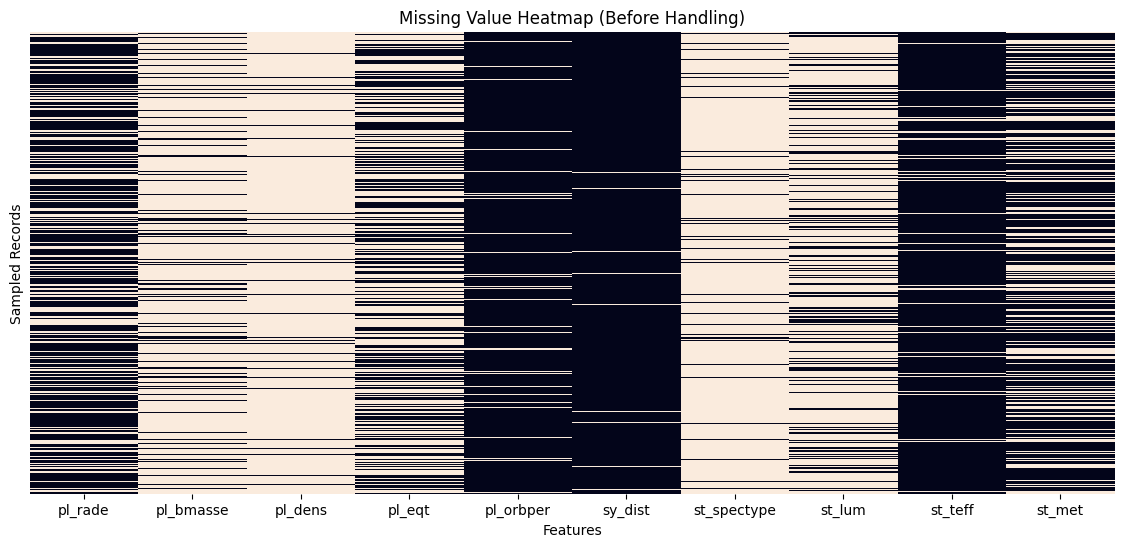

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.heatmap(
    df.sample(2000, random_state=42).isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap (Before Handling)")
plt.xlabel("Features")
plt.ylabel("Sampled Records")
plt.show()

In [30]:
num_cols = [
    'pl_rade', 'pl_bmasse', 'pl_dens', 'pl_eqt','pl_orbper', 'sy_dist','st_lum','st_teff', 'st_met'
]

cat_cols = ['st_spectype']

In [32]:
# Numerical columns
for col in num_cols:
    df.fillna({col: df[col].median()}, inplace=True)

# Categorical columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
df.isnull().sum().sort_values(ascending=False)

pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         0
pl_orbper      0
sy_dist        0
st_spectype    0
st_lum         0
st_teff        0
st_met         0
dtype: int64

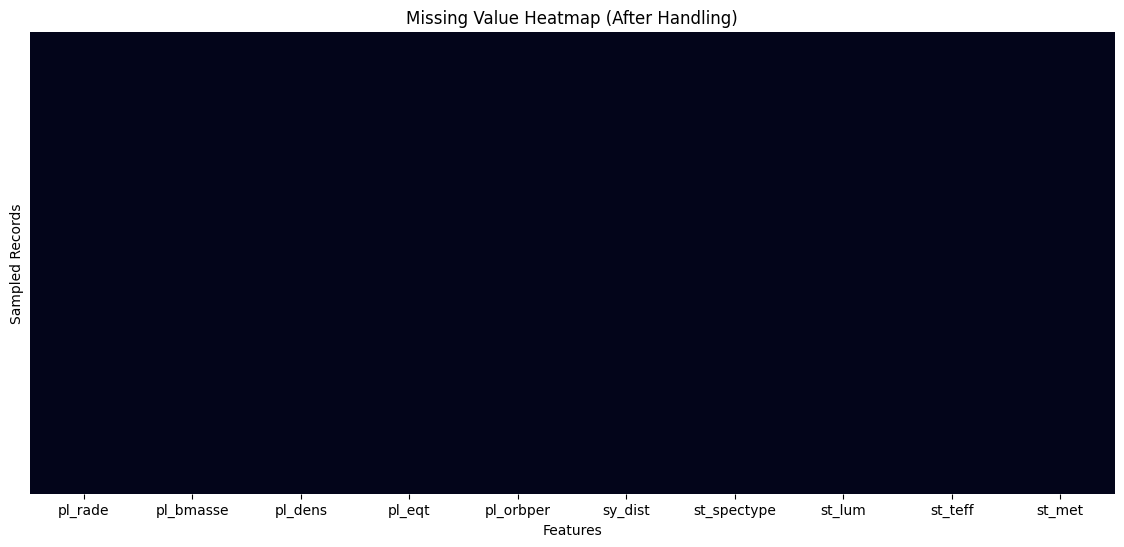

In [34]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.sample(2000, random_state=42).isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap (After Handling)")
plt.xlabel("Features")
plt.ylabel("Sampled Records")
plt.show()


In [35]:
df['st_spectral_class'] = df['st_spectype'].str.extract(r'([OBAFGKM])')
df['st_spectral_class'] = df['st_spectral_class'].fillna('Other')

In [36]:
df.drop(columns=['st_spectype'], inplace=True)

In [37]:
df = pd.get_dummies(
    df,
    columns=['st_spectral_class'],
    drop_first=True
)

In [38]:
df.head()

,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_orbper,sy_dist,st_lum,st_teff,st_met,st_spectral_class_B,st_spectral_class_F,st_spectral_class_G,st_spectral_class_K,st_spectral_class_M,st_spectral_class_Other
0,2.3,5434.700000,1.307,797.0,10.331166,93.1846,-0.08124,5613.0,-0.0014,False,False,True,False,False,False
1,2.3,4914.898486,1.307,797.0,323.210000,93.1846,1.97823,4874.0,-0.2600,False,False,True,False,False,False
2,2.3,6165.600000,1.307,797.0,326.030000,93.1846,2.24300,4742.0,-0.3500,False,False,True,False,False,False
3,2.3,4684.814200,1.307,797.0,516.219970,125.3210,-0.08124,4213.0,-0.0200,False,False,True,False,False,False
4,2.3,3337.070000,1.307,797.0,516.220000,125.3210,-0.08124,4340.0,0.0400,False,False,False,True,False,False


In [39]:
# Convert all boolean columns to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head(20)

,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_orbper,sy_dist,st_lum,st_teff,st_met,st_spectral_class_B,st_spectral_class_F,st_spectral_class_G,st_spectral_class_K,st_spectral_class_M,st_spectral_class_Other
0,2.3,5434.700000,1.307,797.0,10.331166,93.1846,-0.08124,5613.00,-0.0014,0,0,1,0,0,0
1,2.3,4914.898486,1.307,797.0,323.210000,93.1846,1.97823,4874.00,-0.2600,0,0,1,0,0,0
2,2.3,6165.600000,1.307,797.0,326.030000,93.1846,2.24300,4742.00,-0.3500,0,0,1,0,0,0
3,2.3,4684.814200,1.307,797.0,516.219970,125.3210,-0.08124,4213.00,-0.0200,0,0,1,0,0,0
4,2.3,3337.070000,1.307,797.0,516.220000,125.3210,-0.08124,4340.00,0.0400,0,0,0,1,0,0
5,2.3,3432.400000,1.307,797.0,10.331166,125.3210,-0.08124,5613.00,-0.0014,0,0,1,0,0,0
6,2.3,1525.500000,1.307,797.0,185.840000,75.4392,1.76300,4813.00,-0.2400,0,0,0,1,0,0
7,2.3,1131.151301,1.307,797.0,186.760000,75.4392,1.83992,4888.00,-0.2100,0,0,0,1,0,0
8,2.3,1017.000000,1.307,797.0,10.331166,75.4392,-0.08124,5613.00,-0.0014,0,0,1,0,0,0
9,2.3,1581.138000,1.307,797.0,1766.000000,17.9323,-0.15273,5280.00,0.4000,0,0,1,0,0,0


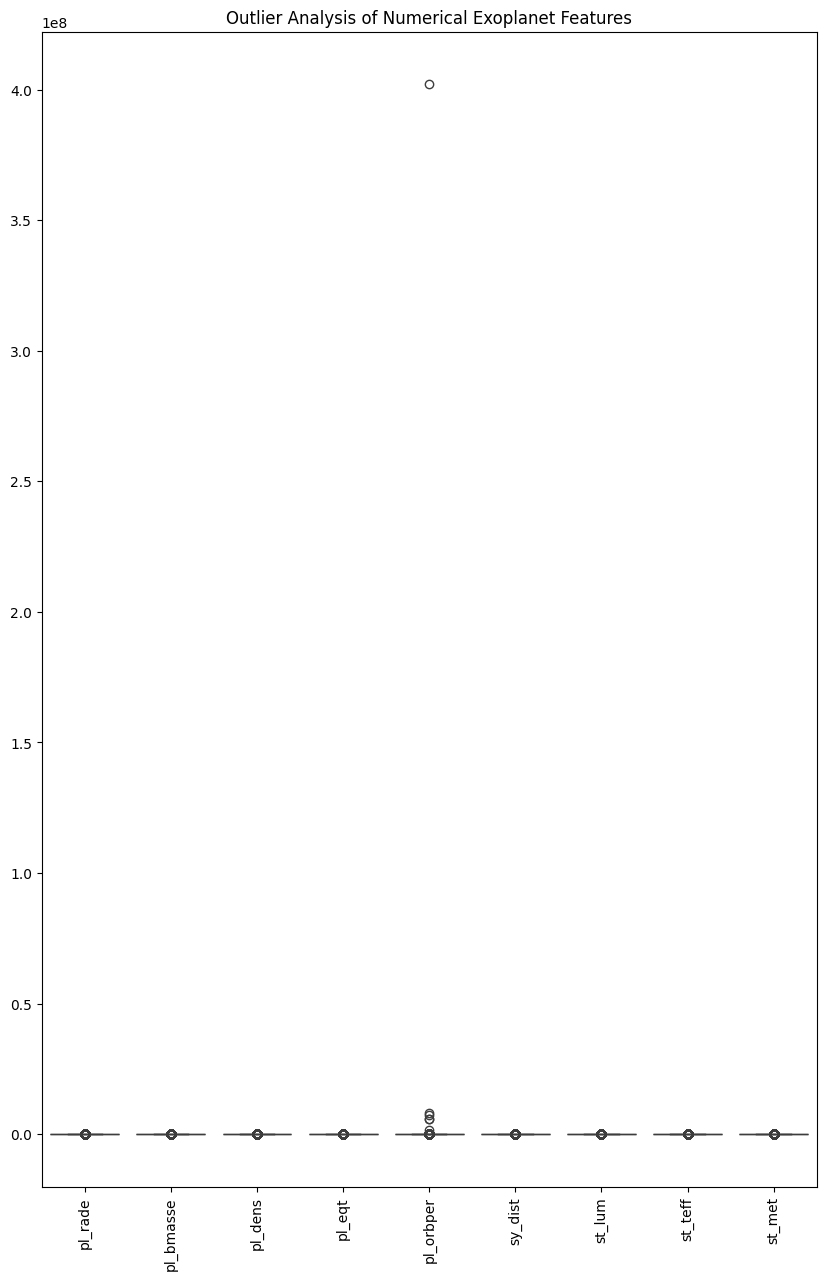

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,15))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Analysis of Numerical Exoplanet Features")
plt.show()

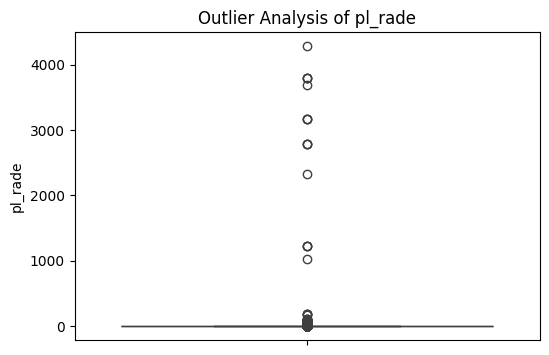

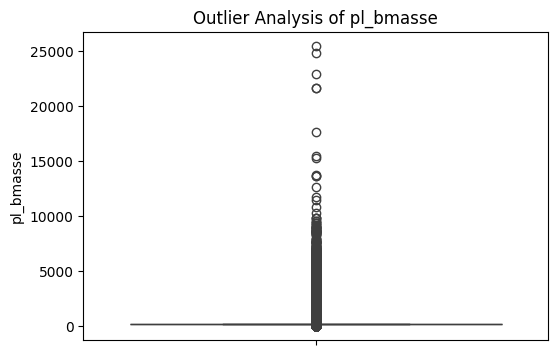

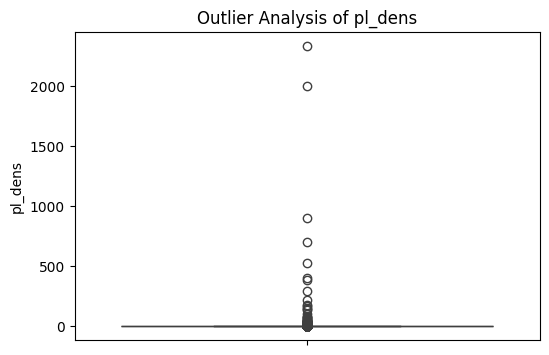

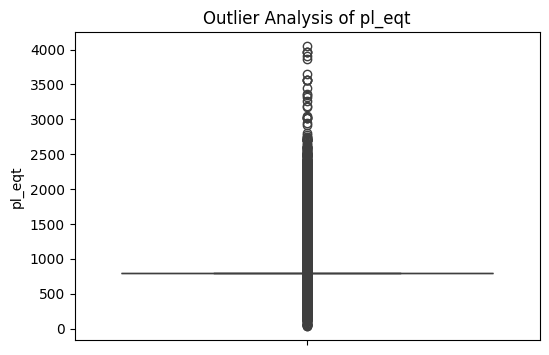

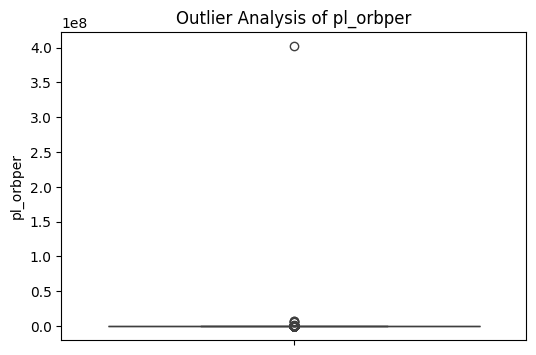

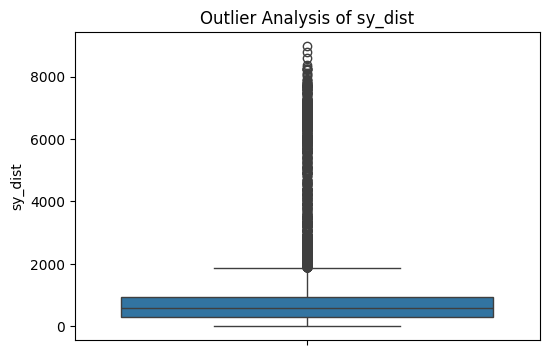

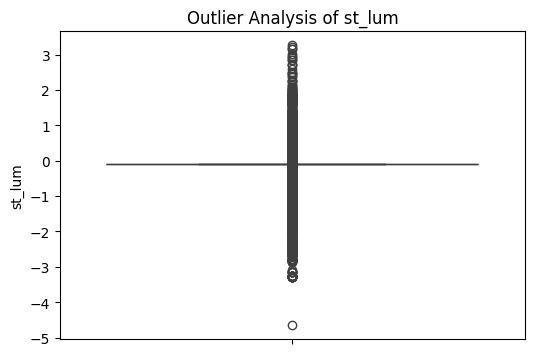

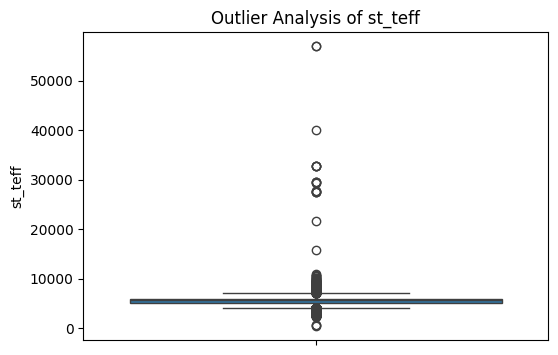

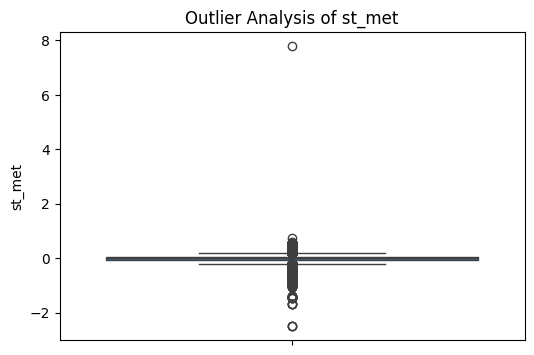

In [41]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Outlier Analysis of {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
df.shape

(39212, 15)

In [42]:
from scipy.stats.mstats import winsorize

df_wins = df.copy()

for col in num_cols:
    df_wins[col] = winsorize(df_wins[col], limits=[0.03, 0.03])

In [43]:
df[num_cols] = df_wins[num_cols]
print("Final dataset shape:", df.shape)

Final dataset shape: (39251, 15)


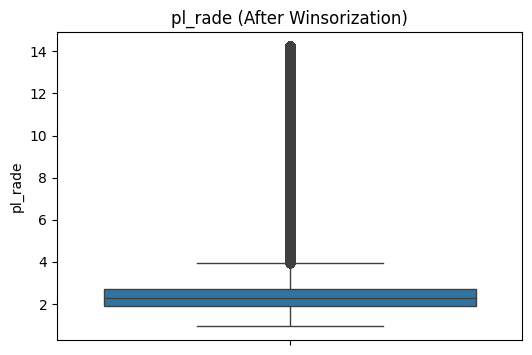

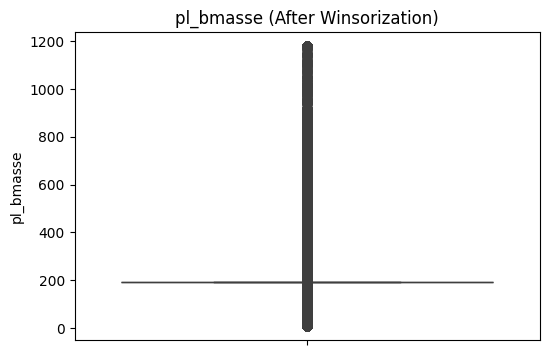

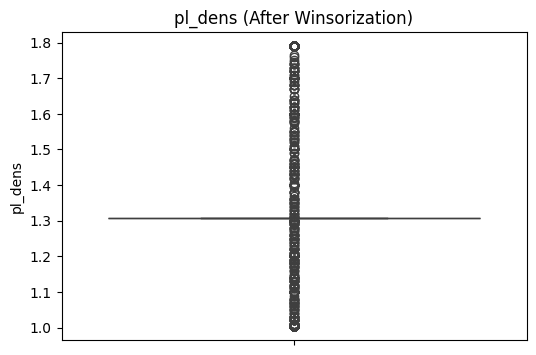

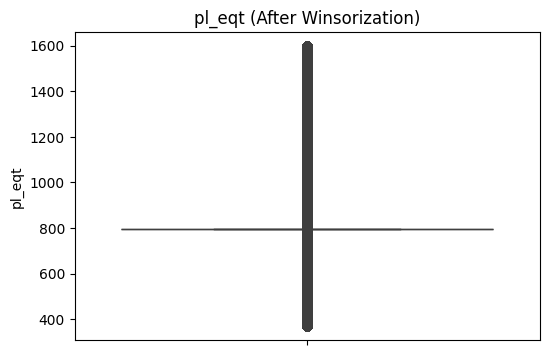

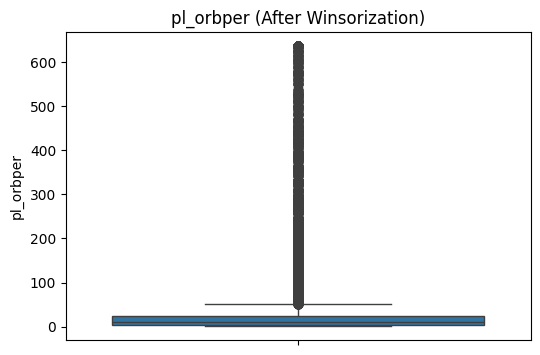

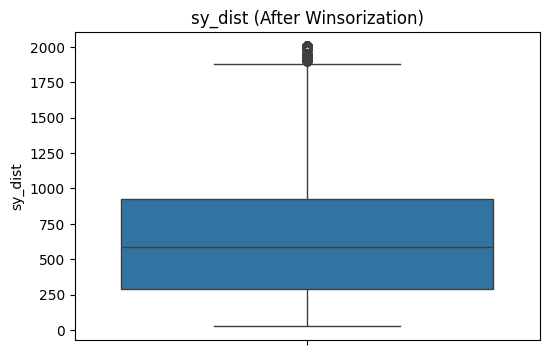

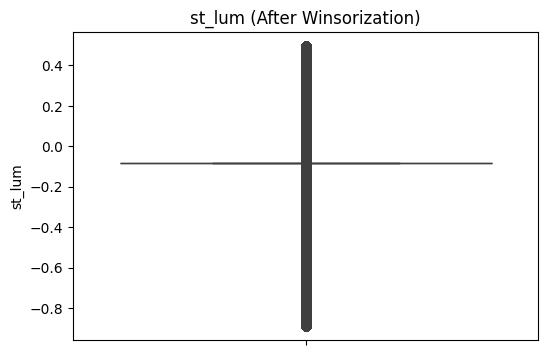

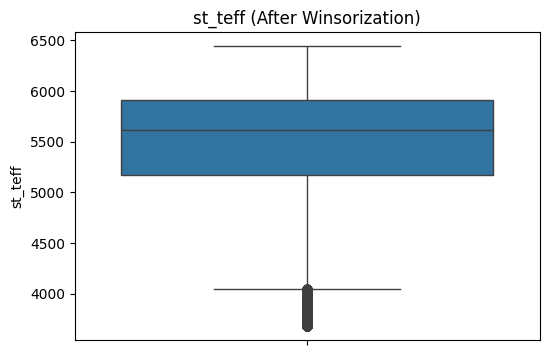

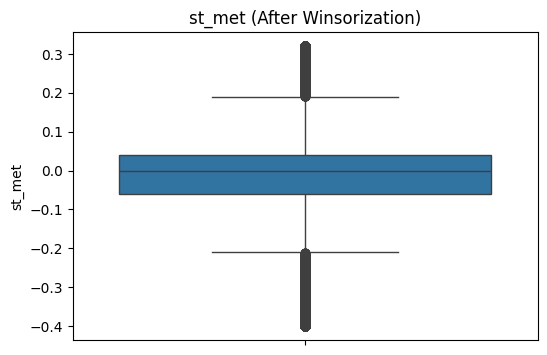

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"{col} (After Winsorization)")
    plt.ylabel(col)
    plt.show()

In [ ]:
print(df.shape)
print(df[num_cols].describe())

(39212, 15)
            pl_rade     pl_bmasse       pl_dens        pl_eqt     pl_orbper  \
count  39212.000000  39212.000000  39212.000000  39212.000000  39212.000000   
mean       3.204908    227.650521      1.325453    826.580225     45.694280   
std        3.068388    201.286107      0.098648    243.395797    120.333469   
min        0.940000      7.530000      1.020000    370.100000      1.252752   
25%        1.880000    192.000000      1.320000    797.000000      4.736209   
50%        2.300000    192.000000      1.320000    797.000000     10.337600   
75%        2.705000    192.000000      1.320000    797.000000     23.668342   
max       14.239500   1175.965106      1.790000   1599.000000    634.600000   

            sy_dist        st_lum       st_teff        st_met  
count  39212.000000  39212.000000  39212.000000  39212.000000  
mean     660.942485     -0.089799   5461.314052     -0.012360  
std      484.087303      0.228387    672.843212      0.153436  
min       26.492700 

In [45]:
#min-max scaling for numerical columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])
df.head(40)

,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_orbper,sy_dist,st_lum,st_teff,st_met,st_spectral_class_B,st_spectral_class_F,st_spectral_class_G,st_spectral_class_K,st_spectral_class_M,st_spectral_class_Other
0,0.102202,1.000000,0.385496,0.347720,0.014299,0.033683,0.583474,0.700072,0.553611,0,0,1,0,0,0
1,0.102202,1.000000,0.385496,0.347720,0.507117,0.033683,1.000000,0.432706,0.194444,0,0,1,0,0,0
2,0.102202,1.000000,0.385496,0.347720,0.511559,0.033683,1.000000,0.384949,0.069444,0,0,1,0,0,0
3,0.102202,1.000000,0.385496,0.347720,0.811129,0.049914,0.583474,0.193560,0.527778,0,0,1,0,0,0
4,0.102202,1.000000,0.385496,0.347720,0.811129,0.049914,0.583474,0.239508,0.611111,0,0,0,1,0,0
5,0.102202,1.000000,0.385496,0.347720,0.014299,0.049914,0.583474,0.700072,0.553611,0,0,1,0,0,0
6,0.102202,1.000000,0.385496,0.347720,0.290745,0.024721,1.000000,0.410637,0.222222,0,0,0,1,0,0
7,0.102202,0.959032,0.385496,0.347720,0.292194,0.024721,1.000000,0.437771,0.263889,0,0,0,1,0,0
8,0.102202,0.861600,0.385496,0.347720,0.014299,0.024721,0.583474,0.700072,0.553611,0,0,1,0,0,0
9,0.102202,1.000000,0.385496,0.347720,1.000000,0.000000,0.531861,0.579595,1.000000,0,0,1,0,0,0


In [46]:
#skewness
df[num_cols].skew()

pl_rade      2.643686
pl_bmasse    3.755191
pl_dens      2.379099
pl_eqt       1.254772
pl_orbper    4.138607
sy_dist      0.897607
st_lum      -0.915402
st_teff     -1.056596
st_met      -0.356475
dtype: float64

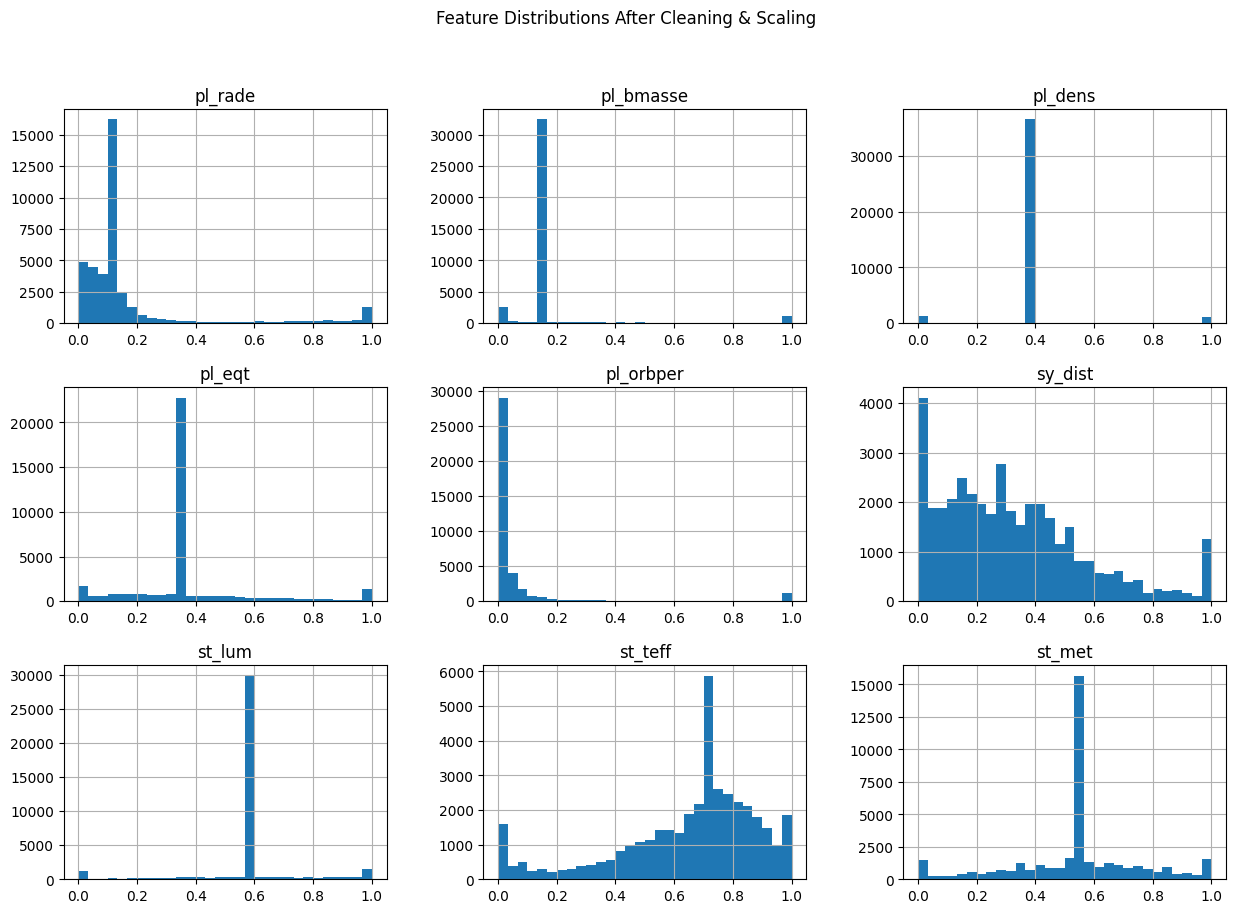

In [47]:
#histogram for features
df[num_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Feature Distributions After Cleaning & Scaling")
plt.show()

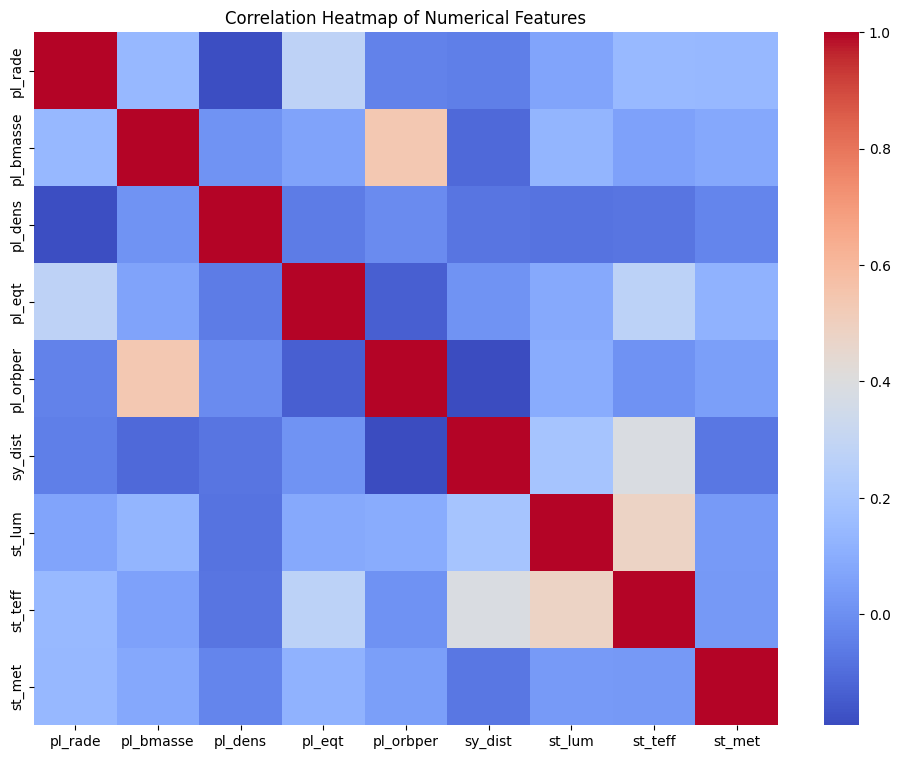

In [48]:
#correlation analysis with the help of heatmap
plt.figure(figsize=(12,9))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [49]:
#Habitibility Score Index
# Define weights (sum = 1.0)
hsi_weights = {
    'pl_rade': 0.25,     # Earth-like size
    'pl_bmasse': 0.20,   # Atmospheric retention
    'pl_dens': 0.20,     # Rocky composition
    'pl_eqt': 0.20,      # Temperature suitability
    'pl_orbper': 0.15    # Climate stability
}

# Compute Habitability Score Index
df['Habitability_Score'] = (
    hsi_weights['pl_rade'] * df['pl_rade'] +
    hsi_weights['pl_bmasse'] * df['pl_bmasse'] +
    hsi_weights['pl_dens'] * df['pl_dens'] +
    hsi_weights['pl_eqt'] * df['pl_eqt'] +
    hsi_weights['pl_orbper'] * df['pl_orbper']
)

# Normalize final score (optional but recommended)
df['Habitability_Score'] = (
    df['Habitability_Score'] - df['Habitability_Score'].min()
) / (
    df['Habitability_Score'].max() - df['Habitability_Score'].min()
)

df[['Habitability_Score']].head(1000)

,Habitability_Score
0,0.386845
1,0.476999
2,0.477812
3,0.532614
4,0.532614
...,...
995,0.179504
996,0.285798
997,0.179504
998,0.285623


In [50]:
spectral_scores = {
    'st_spectral_class_O': 0.0,
    'st_spectral_class_B': 0.1,
    'st_spectral_class_A': 0.2,
    'st_spectral_class_F': 0.4,
    'st_spectral_class_G': 0.7,
    'st_spectral_class_K': 0.85,
    'st_spectral_class_M': 1.0,
    'st_spectral_class_Other': 0.3
}

df['st_spectral_score'] = 0.0

for col, score in spectral_scores.items():
    if col in df.columns:
        df.loc[df[col] == 1, 'st_spectral_score'] = score

In [51]:
df['stellar_compatibility_index'] = (
    0.45 * df['st_spectral_score'] +
    0.25 * (1 - abs(df['st_teff'] - 0.5)) +   # favors Sun-like temps
    0.20 * df['st_lum'] +
    0.10 * df['st_met']
)

In [52]:
df['stellar_compatibility_index'].head(1000)

0      0.687038
1      0.767621
2      0.743182
3      0.657863
4      0.745183
         ...   
995    0.641220
996    0.641220
997    0.659889
998    0.659889
999    0.687038
Name: stellar_compatibility_index, Length: 1000, dtype: float64

In [53]:
#FINAL HABITABILITY SCORE
FINAL_WEIGHTS = {
    'HSI': 0.8,   # Planet properties
    'SCI': 0.2    # Host star influence
}

In [54]:
df['final_habitability_score'] = (
    FINAL_WEIGHTS['HSI'] * df['Habitability_Score'] +
    FINAL_WEIGHTS['SCI'] * df['stellar_compatibility_index']
)

In [55]:
df['final_habitability_score'] = df['final_habitability_score'].clip(0, 1)
df[['Habitability_Score', 'stellar_compatibility_index', 'final_habitability_score']].head(1000)

,Habitability_Score,stellar_compatibility_index,final_habitability_score
0,0.386845,0.687038,0.446883
1,0.476999,0.767621,0.535124
2,0.477812,0.743182,0.530886
3,0.532614,0.657863,0.557664
4,0.532614,0.745183,0.575128
...,...,...,...
995,0.179504,0.641220,0.271847
996,0.285798,0.641220,0.356882
997,0.179504,0.659889,0.275581
998,0.285623,0.659889,0.360476


**MILESTONE 2**

In [56]:
# Define threshold
HABITABLE_THRESHOLD = 0.5

df['habitability_label'] = (df['final_habitability_score'] >= HABITABLE_THRESHOLD).astype(int)

df['habitability_label'].value_counts()

habitability_label
0    36424
1     2827
Name: count, dtype: int64

In [57]:
#Feature Selection
target_col = 'habitability_label'

feature_cols = [
    'pl_rade', 'pl_bmasse', 'pl_dens', 'pl_eqt', 'pl_orbper',
    'sy_dist', 'st_lum', 'st_teff', 'st_met',
    'st_spectral_score'
]

X = df[feature_cols]
y = df[target_col]

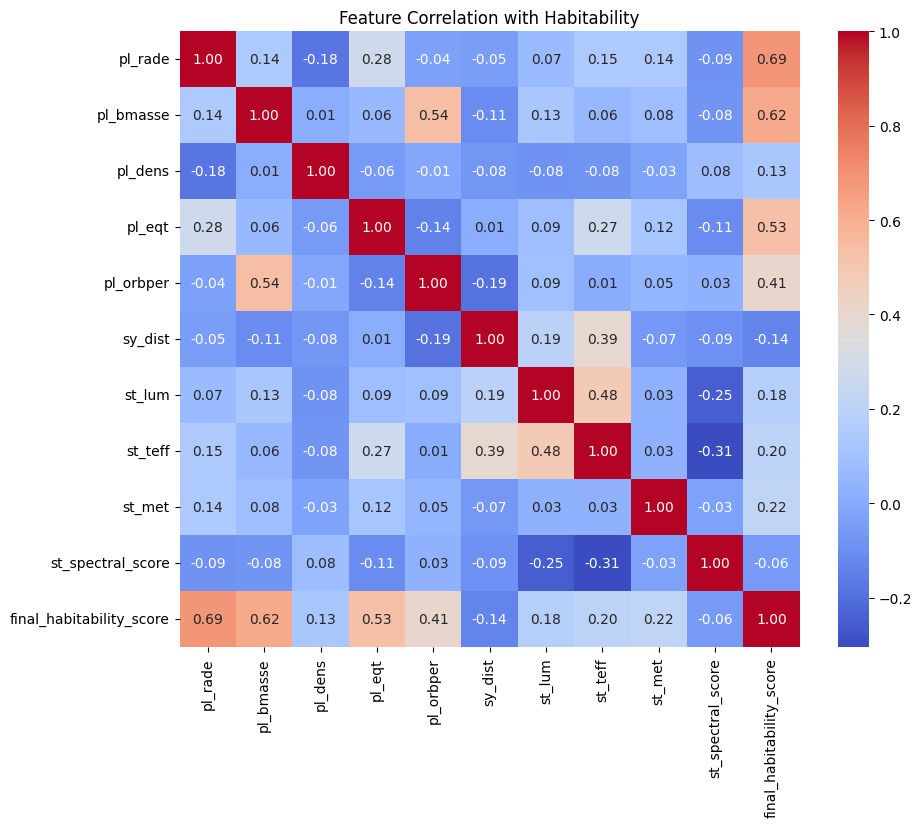

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    df[feature_cols + ['final_habitability_score']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Feature Correlation with Habitability")
plt.show()

In [59]:
#train-test split 80-20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (31400, 10)
Testing set: (7851, 10)


In [60]:
#RandomForestClassifier (Binary)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [63]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [64]:
#RandomForestClassifier Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9910839383518023
Precision: 0.9024390243902439
Recall   : 0.9823008849557522
F1 Score : 0.940677966101695
ROC-AUC  : 0.999312294884844

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      7286
           1       0.90      0.98      0.94       565

    accuracy                           0.99      7851
   macro avg       0.95      0.99      0.97      7851
weighted avg       0.99      0.99      0.99      7851



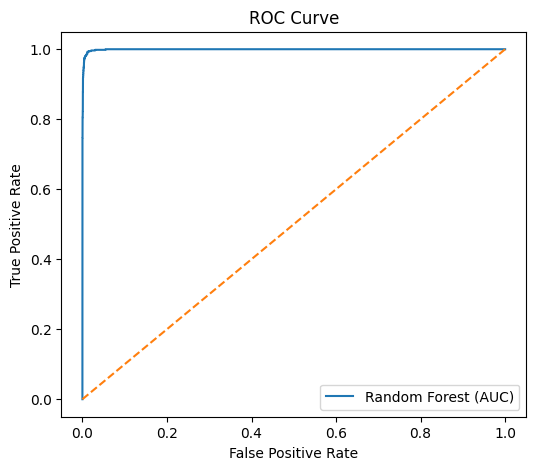

In [65]:
#ROC-CURVE(RandomForestClassifier)
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Random Forest (AUC)')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [66]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
0,pl_rade,0.351948
1,pl_bmasse,0.274259
4,pl_orbper,0.146449
3,pl_eqt,0.122458
5,sy_dist,0.048200
2,pl_dens,0.023617
7,st_teff,0.012196
8,st_met,0.010490
6,st_lum,0.007772
9,st_spectral_score,0.002612


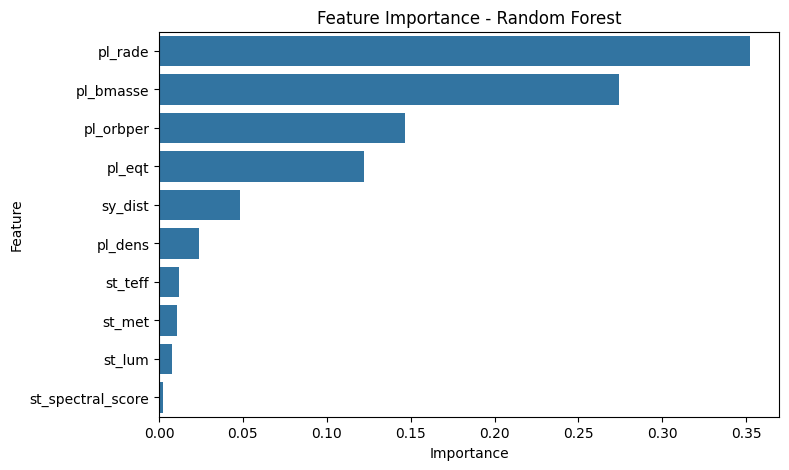

In [67]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance - Random Forest")
plt.show()

In [68]:
#Ranking exoplanets using prediction scores
df['predicted_habitability_prob'] = rf_model.predict_proba(X)[:, 1]

df_sorted = df.sort_values(
    by='predicted_habitability_prob',
    ascending=False
)

df_sorted[['predicted_habitability_prob']].head()

,predicted_habitability_prob
37047,0.999765
915,0.999699
27033,0.999686
1584,0.999684
1840,0.999682


In [72]:
#Logistic regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression

# Define the model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

In [73]:
# Metrics
accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred)
recall = recall_score(y_test, lr_pred)
f1 = f1_score(y_test, lr_pred)
roc_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Performance:
Accuracy  : 0.9959
Precision : 0.9908
Recall    : 0.9522
F1-score  : 0.9711
ROC-AUC   : 0.9999

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7286
           1       0.99      0.95      0.97       565

    accuracy                           1.00      7851
   macro avg       0.99      0.98      0.98      7851
weighted avg       1.00      1.00      1.00      7851



In [77]:
#XGBoost multiclass
def habitability_class(score):
    if score < 0.4:
        return 0   # Non-Habitable
    elif score < 0.65:
        return 1   # Potentially Habitable
    else:
        return 2   # Highly Habitable

df['habitability_multiclass'] = df['final_habitability_score'].apply(habitability_class)

df['habitability_multiclass'].value_counts()

habitability_multiclass
0    33714
1     5185
2      352
Name: count, dtype: int64

In [78]:
target_col = 'habitability_multiclass'

feature_cols = [
    'pl_rade', 'pl_bmasse', 'pl_dens', 'pl_eqt', 'pl_orbper',
    'sy_dist', 'st_lum', 'st_teff', 'st_met',
    'st_spectral_score'
]

X = df[feature_cols]
y = df[target_col]

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [81]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [82]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)

In [83]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        'Non-Habitable',
        'Potentially Habitable',
        'Highly Habitable'
    ]
))

                       precision    recall  f1-score   support

        Non-Habitable       1.00      1.00      1.00      6744
Potentially Habitable       0.97      0.98      0.97      1037
     Highly Habitable       0.96      0.93      0.94        70

             accuracy                           0.99      7851
            macro avg       0.97      0.97      0.97      7851
         weighted avg       0.99      0.99      0.99      7851



In [84]:
#overall classification report
from sklearn.metrics import accuracy_score

print("Overall Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import precision_score, recall_score, f1_score

print("Overall Precision (weighted):",
      precision_score(y_test, y_pred, average='weighted'))

print("Overall Recall (weighted):",
      recall_score(y_test, y_pred, average='weighted'))

print("Overall F1-score (weighted):",
      f1_score(y_test, y_pred, average='weighted'))

Overall Accuracy: 0.9929945229907018
Overall Precision (weighted): 0.9930426673004119
Overall Recall (weighted): 0.9929945229907018
Overall F1-score (weighted): 0.9930094026585551


In [85]:
from sklearn.metrics import roc_auc_score

y_prob = xgb_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("Overall ROC-AUC (OVR, weighted):", roc_auc)

Overall ROC-AUC (OVR, weighted): 0.9997680343594626


In [86]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
0,pl_rade,0.363509
1,pl_bmasse,0.310342
3,pl_eqt,0.089369
4,pl_orbper,0.078255
2,pl_dens,0.076238
5,sy_dist,0.019118
8,st_met,0.018891
6,st_lum,0.016049
7,st_teff,0.015687
9,st_spectral_score,0.012543


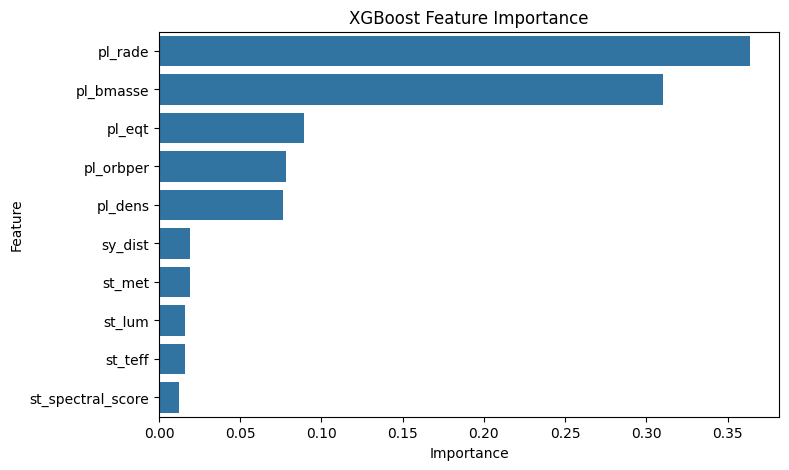

In [87]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)
plt.title("XGBoost Feature Importance")
plt.show()

### Model Comparison Between different models



| Model               | Classification Type | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| ------------------- | ------------------- | -------- | --------- | ------ | -------- | ------- |
| Logistic Regression | Binary              | 0.9959   | 0.9908    | 0.9522 | 0.9711   | 0.9999  |
| Random Forest       | Binary              | 0.9910   | 0.9024    | 0.9823 | 0.9406   | 0.9993  |
| XGBoost             | Multi-class (3)     | 0.9929   | 0.9936    | 0.9930 | 0.9929   | 0.99976 |


#### Model Performance Summary

#### Key Insights for ExoHabitAI

In [91]:
import joblib
import os

# Create the models directory if it doesn't exist
model_dir = r"D:\Exo_Habit-AI\models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 1. Save the XGBoost Model (Best Performer)
# Replace 'xgb_model' with the variable name of your trained XGBoost model
joblib.dump(xgb_model, os.path.join(model_dir, "xgboost_model.pkl"))

# 2. Save the Scaler
# Replace 'scaler' with the variable name of your fitted StandardScaler
joblib.dump(scaler, os.path.join(model_dir, "scaler.pkl"))

# 3. Save the Feature Order (Crucial for consistent API predictions)
# Replace 'X_train' with the variable name of your training feature set
feature_order = X_train.columns.tolist()
joblib.dump(feature_order, os.path.join(model_dir, "feature_order.pkl"))

print(f"✅ Success! 3 files saved in {model_dir}")

✅ Success! 3 files saved in D:\Exo_Habit-AI\models


In [104]:
# Save the cleaned data to disk
df_final.to_csv(r"D:\Exo_Habit-AI\processed_exoplanets.csv", index=False)

In [106]:
# save_models.py - Run this once to save your trained models
import joblib
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Save models (run after training)
joblib.dump(rf_model, 'models/rf_model.pkl')
joblib.dump(xgb_model, 'models/xgb_model.pkl')
joblib.dump(scaler, 'data/scaler.pkl')

print("Models saved successfully!")


Models saved successfully!
